# ⏩ **WOMEN'S CAREER RECOMMENDATION SYSTEM USING MACHINE LEARNING**


# ♦ **Problem Statement**
🎯 Career Selection Challenge: Women may face difficulty in identifying a career path that matches their individual profile.

🧩 Multiple Factors: Career selection depends on technical skills, fields of interest, skills gained, qualification, stream, academic performance, certifications, and work-type preferences.

👤 Lack of Personalization: Traditional career guidance may provide general suggestions rather than recommendations based on an individual's complete profile.

⏳ Manual Evaluation: Considering multiple career options and comparing them with personal skills and qualifications can be time-consuming.

📊 Complex Career Data: Career-related data contains patterns that may be difficult to identify manually.

🤖 Need for ML: A Machine Learning approach can analyze these factors and learn patterns from career-related data.

💡 Problem to Solve: There is a need for a system that can use an individual's profile to recommend suitable career options in a personalized and data-driven manner.

# ♦ Objectives
🎯 Develop a Machine Learning-based system to recommend suitable career paths for women.

📊 Analyze user profiles based on technical skills, fields of interest, skills gained, qualification, stream, academic performance, certifications, and work-type interest.

🧠 Train a Machine Learning model to identify patterns between user profiles and suitable career options.

👤 Provide personalized career recommendations based on individual user characteristics.

💡 Support better career exploration by matching users with career options relevant to their profiles.

💻 Create a simple and user-friendly system for entering profile details and viewing recommendations.

📈 Improve the efficiency of career selection compared with manually evaluating multiple career options.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, MultiLabelBinarizer, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
import warnings

warnings.filterwarnings("ignore")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
df=pd.read_csv("Womens_Career_Recommendation_Dataset_5000_Balanced.csv")
df.head()

,Age,Education,Degree,Skills,Technical Skills,Soft Skills,Work Experience,Interests,Career Interests,Personality/Strengths,Preferred Work Environment,Salary Expectation,Location Preference,Work-Life Balance Preference,Recommended_Career
0,20,Undergraduate,BBA,"Analysis, Programming","SQL, Tableau, Excel","Teamwork, Time Management, Problem Solving",0 years,"Business Intelligence, Analytics",Data Analytics,"Analytical, Curious",Office,86925,Remote,High,Data Analyst
1,33,Diploma,BCA,"Analysis, Programming","Python, SQL, Excel, MS Office","Communication, Creativity, Teamwork",3 years,"Branding, Social Media",Digital Marketing,"Creative, Persuasive",Hybrid,77542,Remote,Medium,Marketing Manager
2,28,Undergraduate,M.Sc,"Leadership, Communication","Machine Learning, Python, SQL","Teamwork, Creativity, Adaptability",0 years,"Branding, Social Media",Marketing,"Analytical, Innovative",Hybrid,56619,Remote,Low,Marketing Manager
3,28,Postgraduate,MA,"Research, Communication","SPSS, Excel, Statistics","Teamwork, Creativity, Adaptability",7 years,"Education, Research",Academic Research,"Analytical, Curious",Remote,81475,Hyderabad,Medium,Academic Researcher
4,27,Undergraduate,M.Sc,"Research, Programming","SEO, Digital Marketing, Excel, UI Design","Leadership, Time Management, Critical Thinking",5 years,"Data Science, Technology",Data Analytics,"Leadership, Communication",Hybrid,72089,Mumbai,Medium,Marketing Manager


## Load Dataset

## Understand Data

In [ ]:
df.shape


(5000, 15)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   Age                           5000 non-null   int64 
 1   Education                     5000 non-null   object
 2   Degree                        5000 non-null   object
 3   Skills                        5000 non-null   object
 4   Technical Skills              5000 non-null   object
 5   Soft Skills                   5000 non-null   object
 6   Work Experience               5000 non-null   object
 7   Interests                     5000 non-null   object
 8   Career Interests              5000 non-null   object
 9   Personality/Strengths         5000 non-null   object
 10  Preferred Work Environment    5000 non-null   object
 11  Salary Expectation            5000 non-null   int64 
 12  Location Preference           5000 non-null   object
 13  Work-Life Balance 

In [ ]:
df.describe()

,Age,Salary Expectation
count,5000.000000,5000.000000
mean,32.430200,76661.591800
std,7.544913,19571.075887
min,20.000000,32586.000000
25%,26.000000,61679.500000
50%,33.000000,76750.500000
75%,39.000000,90200.000000
max,45.000000,135069.000000


## Clean Data

In [ ]:
df.isnull().sum()

,0
Age,0
Education,0
Degree,0
Skills,0
Technical Skills,0
Soft Skills,0
Work Experience,0
Interests,0
Career Interests,0
Personality/Strengths,0


In [ ]:
df.duplicated().sum()

np.int64(0)

## EDA

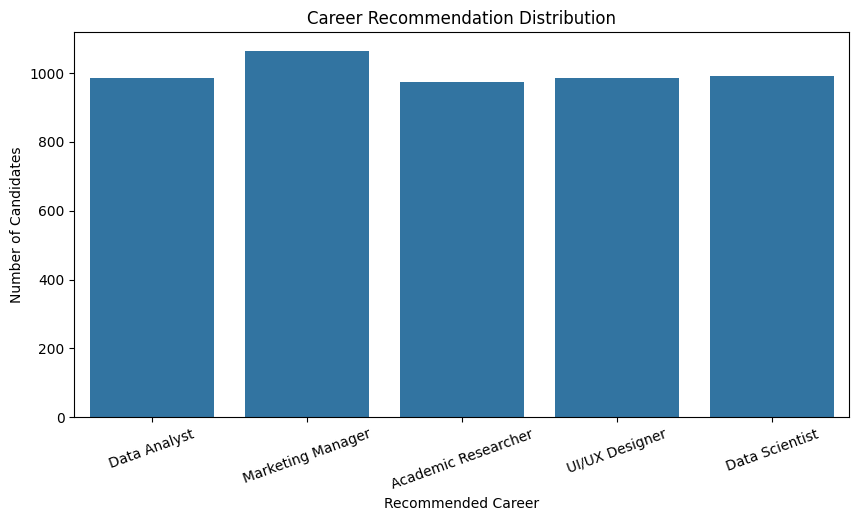

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="Recommended_Career")
plt.xticks(rotation=20)
plt.title("Career Recommendation Distribution")
plt.xlabel("Recommended Career")
plt.ylabel("Number of Candidates")
plt.show()

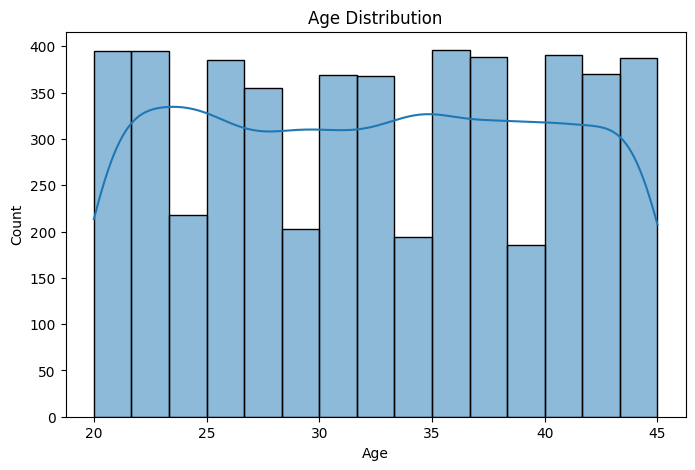

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=15, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

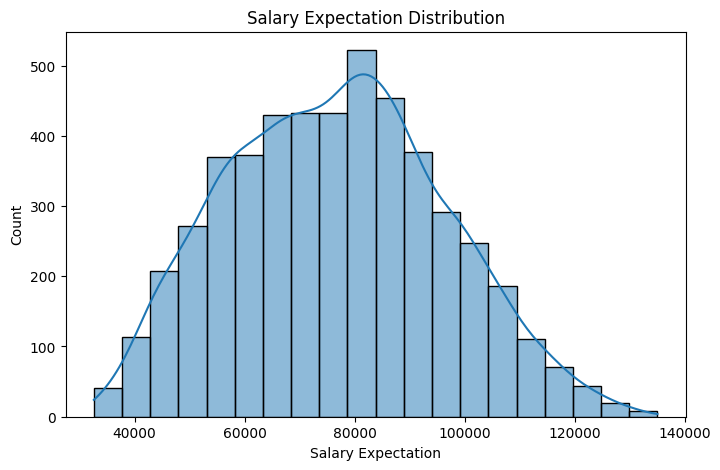

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["Salary Expectation"], bins=20, kde=True)
plt.title("Salary Expectation Distribution")
plt.xlabel("Salary Expectation")
plt.ylabel("Count")
plt.show()

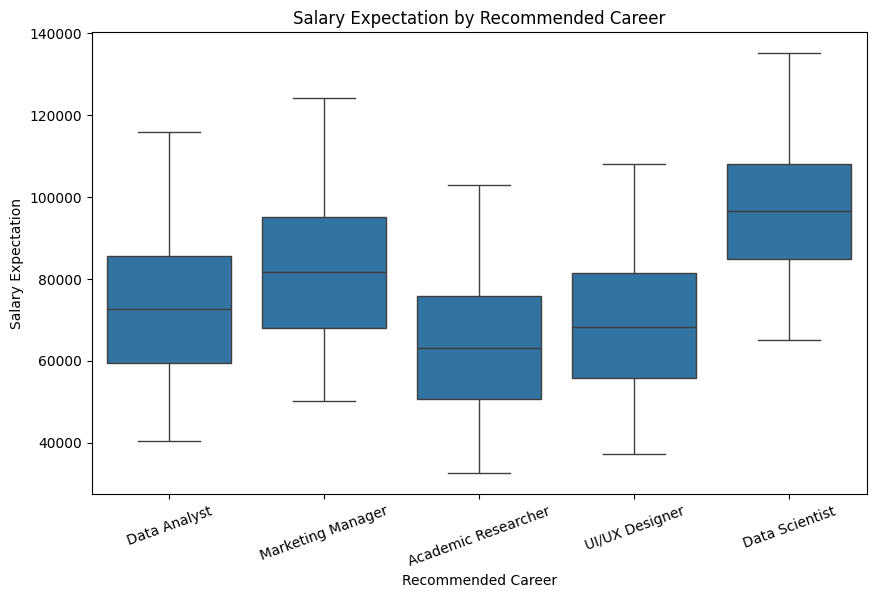

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="Recommended_Career", y="Salary Expectation")
plt.xticks(rotation=20)
plt.title("Salary Expectation by Recommended Career")
plt.xlabel("Recommended Career")
plt.ylabel("Salary Expectation")
plt.show()

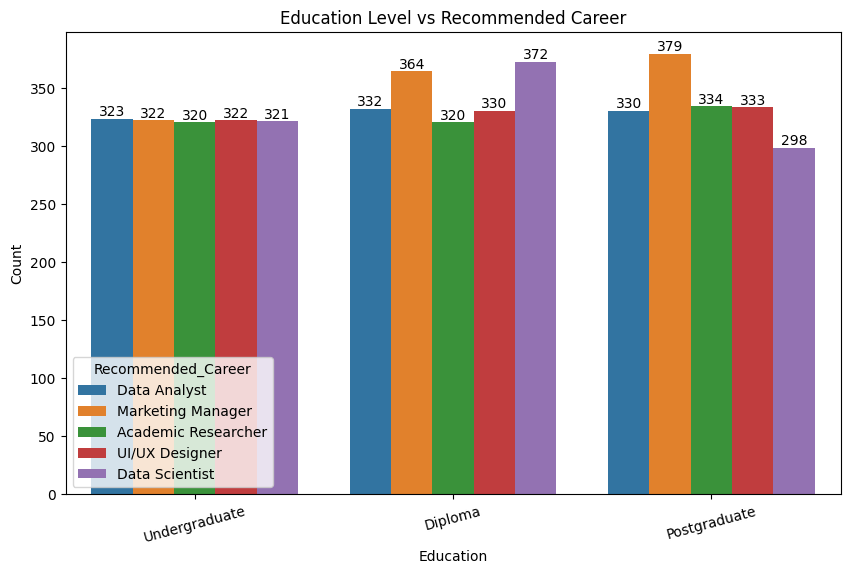

In [ ]:
plt.figure(figsize=(10,6))
ax=sns.countplot(data=df, x="Education", hue="Recommended_Career")
for c in ax.containers:
    ax.bar_label(c)
plt.xticks(rotation=15)
plt.title("Education Level vs Recommended Career")
plt.xlabel("Education")
plt.ylabel("Count")
plt.show()

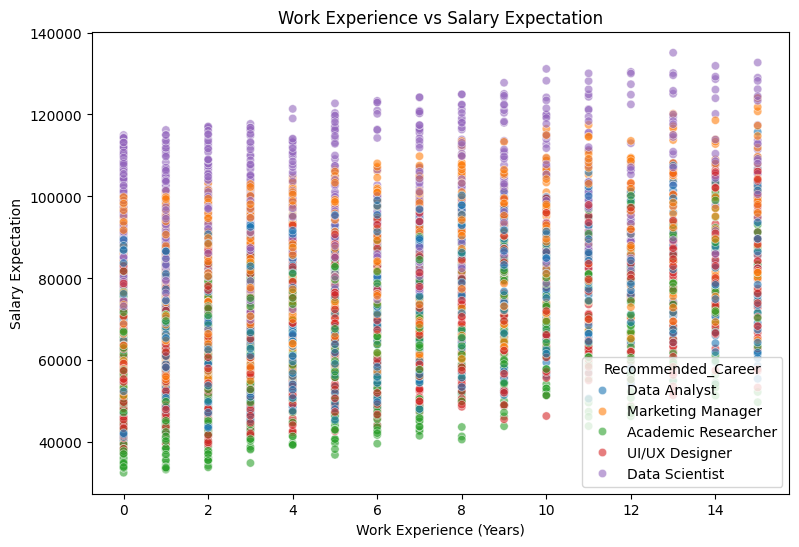

In [ ]:
df["Experience_Years"] = (
    df["Work Experience"]
    .str.extract(r"(\d+)")
    .astype(int)
)

plt.figure(figsize=(9,6))
sns.scatterplot(
    data=df,
    x="Experience_Years",
    y="Salary Expectation",
    hue="Recommended_Career",
    alpha=0.6
)
plt.title("Work Experience vs Salary Expectation")
plt.xlabel("Work Experience (Years)")
plt.ylabel("Salary Expectation")
plt.show()

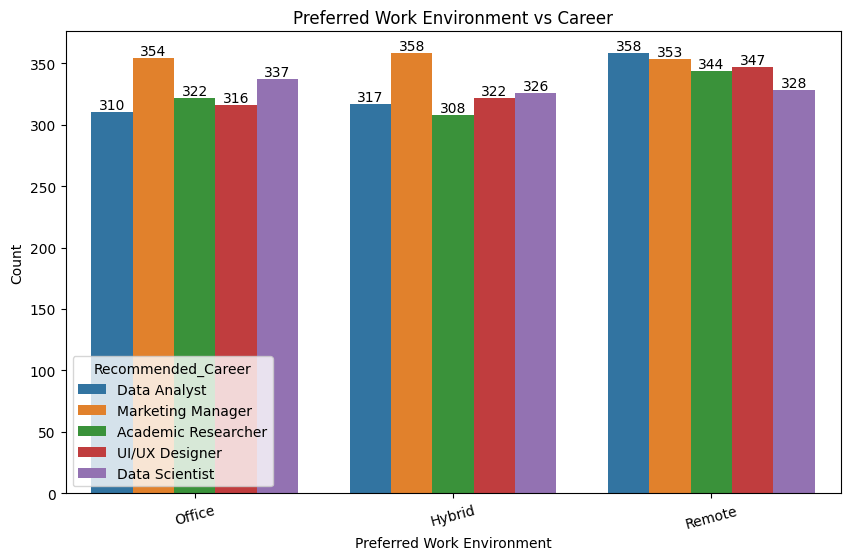

In [ ]:
plt.figure(figsize=(10,6))
ax=sns.countplot(
    data=df,
    x="Preferred Work Environment",
    hue="Recommended_Career"
)
for c in ax.containers:
    ax.bar_label(c)
plt.xticks(rotation=15)
plt.title("Preferred Work Environment vs Career")
plt.xlabel("Preferred Work Environment")
plt.ylabel("Count")
plt.show()

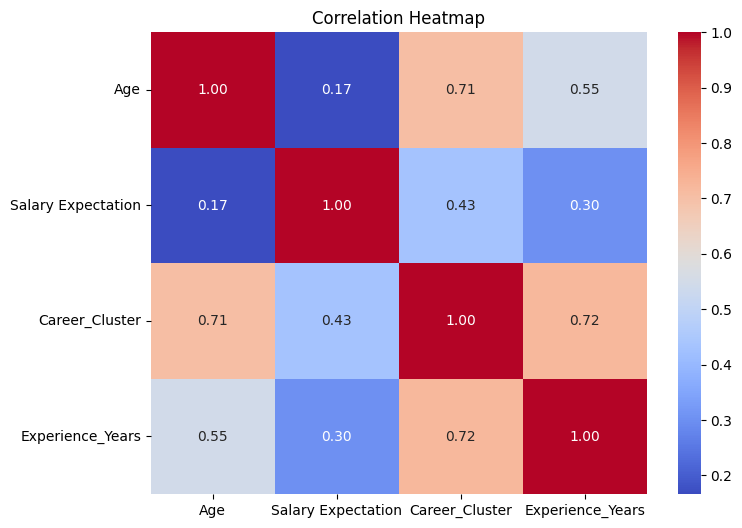

In [ ]:
plt.figure(figsize=(8,6))

numeric_df = df.select_dtypes(include="number")

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

## Supervised Machine Learning

In [ ]:
# Target and input features

df.columns = df.columns.str.strip()

TARGET = "Recommended_Career"

X = df.drop(columns=[TARGET])
y = df[TARGET]

multi_label_columns = [
    "Skills",
    "Technical Skills",
    "Soft Skills",
    "Interests",
    "Personality/Strengths"
]

def split_values(value):
    if pd.isna(value):
        return []
    value = str(value).strip()
    if value == "":
        return []
    return [item.strip() for item in value.split(",") if item.strip()]


In [ ]:
# MultiLabelBinarizer

mlb_dict = {}

X_processed = X.drop(
    columns=multi_label_columns
).copy()

for col in multi_label_columns:

    values = X[col].apply(split_values)

    mlb = MultiLabelBinarizer()

    encoded = mlb.fit_transform(values)

    encoded_df = pd.DataFrame(
        encoded,
        columns=[f"{col}_{item}" for item in mlb.classes_],
        index=X.index
    )

    X_processed = pd.concat(
        [X_processed, encoded_df],
        axis=1
    )

    mlb_dict[col] = mlb

print("Processed Shape:", X_processed.shape)


Processed Shape: (5000, 66)


In [ ]:
# Convert Work Experience to numeric

def convert_experience(value):
    if pd.isna(value):
        return 0

    value = str(value).strip()

    if "10+" in value:
        return 10

    try:
        return int(value.split()[0])
    except:
        return 0

X_processed["Work Experience"] = (
    X_processed["Work Experience"]
    .apply(convert_experience)
)

numeric_features = [
    "Age",
    "Work Experience",
    "Salary Expectation"
]

categorical_features = [
    "Education",
    "Degree",
    "Career Interests",
    "Preferred Work Environment",
    "Location Preference",
    "Work-Life Balance Preference"
]


In [ ]:
# Preprocessing

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
], remainder="passthrough")

X_train, X_test, y_train, y_test = train_test_split(
    X_processed,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Records:", len(X_train))
print("Testing Records:", len(X_test))


Training Records: 4000
Testing Records: 1000


In [ ]:
# Train and compare models

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    "SVM": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

results = {}
trained_models = {}

for model_name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    results[model_name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(
            y_test, y_pred,
            average="weighted",
            zero_division=0
        ),
        "Recall": recall_score(
            y_test, y_pred,
            average="weighted",
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_test, y_pred,
            average="weighted",
            zero_division=0
        )
    }

    trained_models[model_name] = pipeline

results_df = pd.DataFrame(results).T

display(
    (results_df * 100).round(2)
)


,Accuracy,Precision,Recall,F1 Score
Logistic Regression,96.3,96.34,96.3,96.30
Decision Tree,88.0,88.11,88.0,88.01
Random Forest,94.8,94.83,94.8,94.81
SVM,96.0,96.02,96.0,96.00
KNN,93.3,93.37,93.3,93.31


In [ ]:
# Select and save best model

best_model_name = results_df["Accuracy"].idxmax()

best_model = trained_models[best_model_name]

best_predictions = best_model.predict(X_test)

print("Best Model:", best_model_name)
print(
    "Best Accuracy:",
    round(
        results_df.loc[best_model_name, "Accuracy"] * 100,
        2
    ),
    "%"
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        best_predictions,
        zero_division=0
    )
)

print("Confusion Matrix:")
print(
    confusion_matrix(
        y_test,
        best_predictions
    )
)

joblib.dump(
    best_model,
    "/content/women_career_model.pkl"
)

joblib.dump(
    mlb_dict,
    "/content/multi_label_binarizers.pkl"
)

print("\nSaved:")
print("women_career_model.pkl")
print("multi_label_binarizers.pkl")


Best Model: Logistic Regression
Best Accuracy: 96.3 %

Classification Report:

                     precision    recall  f1-score   support

Academic Researcher       0.98      0.95      0.97       195
       Data Analyst       0.94      0.95      0.95       197
     Data Scientist       0.98      0.95      0.96       198
  Marketing Manager       0.95      0.99      0.97       213
     UI/UX Designer       0.96      0.97      0.97       197

           accuracy                           0.96      1000
          macro avg       0.96      0.96      0.96      1000
       weighted avg       0.96      0.96      0.96      1000

Confusion Matrix:
[[186   3   1   2   3]
 [  2 187   1   4   3]
 [  0   5 188   3   2]
 [  0   2   1 210   0]
 [  1   1   1   2 192]]

Saved:
women_career_model.pkl
multi_label_binarizers.pkl


## Unsupervised Machine Learning

In [ ]:
# K-Means Clustering

cluster_preprocessor = ColumnTransformer([
    (
        "numeric",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]),
        numeric_features
    ),
    (
        "categorical",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]),
        categorical_features
    )
], remainder="passthrough")

cluster_data = cluster_preprocessor.fit_transform(
    X_processed
)

silhouette_scores = {}

for k in range(2, 8):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(
        cluster_data
    )

    score = silhouette_score(
        cluster_data,
        labels
    )

    silhouette_scores[k] = score

    print(
        f"K={k} | Silhouette Score={score:.4f}"
    )

best_k = max(
    silhouette_scores,
    key=silhouette_scores.get
)

print("\nBest K:", best_k)

final_kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

df["Career_Cluster"] = final_kmeans.fit_predict(
    cluster_data
)

joblib.dump(
    final_kmeans,
    "/content/kmeans_model.pkl"
)

joblib.dump(
    cluster_preprocessor,
    "/content/cluster_preprocessor.pkl"
)

df.to_excel(
    "/content/women_career_dataset_with_clusters.xlsx",
    index=False
)

print("\nCluster files and updated dataset saved.")


K=2 | Silhouette Score=0.0707
K=3 | Silhouette Score=0.0582
K=4 | Silhouette Score=0.0602
K=5 | Silhouette Score=0.0678
K=6 | Silhouette Score=0.0670
K=7 | Silhouette Score=0.0637

Best K: 2

Cluster files and updated dataset saved.
